## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# ── Palette
PRIMARY = "#4F46E5"
ACCENT  = "#10B981"
WARN    = "#F59E0B"
DANGER  = "#EF4444"
BG      = "#F8FAFC"
CARD    = "#FFFFFF"
TEXT    = "#1E293B"
GRID    = "#E2E8F0"
PALETTE = [PRIMARY, ACCENT, WARN, DANGER, "#8B5CF6", "#06B6D4"]

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   CARD,
    "axes.edgecolor":   GRID,
    "axes.labelcolor":  TEXT,
    "axes.titlecolor":  TEXT,
    "xtick.color":      TEXT,
    "ytick.color":      TEXT,
    "grid.color":       GRID,
    "grid.linewidth":   0.7,
    "font.family":      "DejaVu Sans",
    "font.size":        10,
})

print('Setup complete ✓')

Setup complete ✓


## 2. Load Data

In [2]:
df = pd.read_csv("data.csv")

features = ["footfall","tempMode","AQ","USS","CS","VOC","RP","IP","Temperature"]
target   = "fail"

print(f"Shape: {df.shape}")
df.head(10)

Shape: (944, 10)


,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
0,0,7,7,1,6,6,36,3,1,1
1,190,1,3,3,5,1,20,4,1,0
2,31,7,2,2,6,1,24,6,1,0
3,83,4,3,4,5,1,28,6,1,0
4,640,7,5,6,4,0,68,6,1,0
5,110,3,3,4,6,1,21,4,1,0
6,100,7,5,6,4,1,77,4,1,0
7,31,1,5,4,5,4,21,4,1,0
8,180,7,4,6,3,3,31,4,1,0
9,2800,0,3,3,7,0,39,3,1,0


In [3]:
df.describe()

,footfall,tempMode,AQ,USS,CS,VOC,RP,IP,Temperature,fail
count,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000
mean,306.381356,3.727754,4.325212,2.939619,5.394068,2.842161,47.043432,4.565678,16.331568,0.416314
std,1082.606745,2.677235,1.438436,1.383725,1.269349,2.273337,16.423130,1.599287,5.974781,0.493208
min,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,19.000000,1.000000,1.000000,0.000000
25%,1.000000,1.000000,3.000000,2.000000,5.000000,1.000000,34.000000,3.000000,14.000000,0.000000
50%,22.000000,3.000000,4.000000,3.000000,6.000000,2.000000,44.000000,4.000000,17.000000,0.000000
75%,110.000000,7.000000,6.000000,4.000000,6.000000,5.000000,58.000000,6.000000,21.000000,1.000000
max,7300.000000,7.000000,7.000000,7.000000,7.000000,6.000000,91.000000,7.000000,24.000000,1.000000


## 3. Missing Value Analysis & Handling

In [4]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Missing Value Summary:")
print(missing_df)

Missing Value Summary:
             Missing Count  Missing %
footfall                 0        0.0
tempMode                 0        0.0
AQ                       0        0.0
USS                      0        0.0
CS                       0        0.0
VOC                      0        0.0
RP                       0        0.0
IP                       0        0.0
Temperature              0        0.0
fail                     0        0.0


In [5]:
# Fill numeric columns with median (robust to skew)
missing_before = df.isnull().sum().sum()
for col in features:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)
missing_after = df.isnull().sum().sum()
print(f"Missing values — Before: {missing_before}  →  After: {missing_after}")

Missing values — Before: 0  →  After: 0


## 4. Outlier Detection & Capping (IQR Method)

In [6]:
outlier_summary = {}
for col in features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_summary[col] = {'Lower Bound': round(lo,2), 'Upper Bound': round(hi,2),
                             'Outliers Detected': n_out}
    df[col] = df[col].clip(lo, hi)

outlier_df = pd.DataFrame(outlier_summary).T
print("Outlier Summary (IQR × 1.5 capping):")
print(outlier_df)

Outlier Summary (IQR × 1.5 capping):
             Lower Bound  Upper Bound  Outliers Detected
footfall          -162.5        273.5              154.0
tempMode            -8.0         16.0                0.0
AQ                  -1.5         10.5                0.0
USS                 -1.0          7.0                0.0
CS                   3.5          7.5               87.0
VOC                 -5.0         11.0                0.0
RP                  -2.0         94.0                0.0
IP                  -1.5         10.5                0.0
Temperature          3.5         31.5               48.0


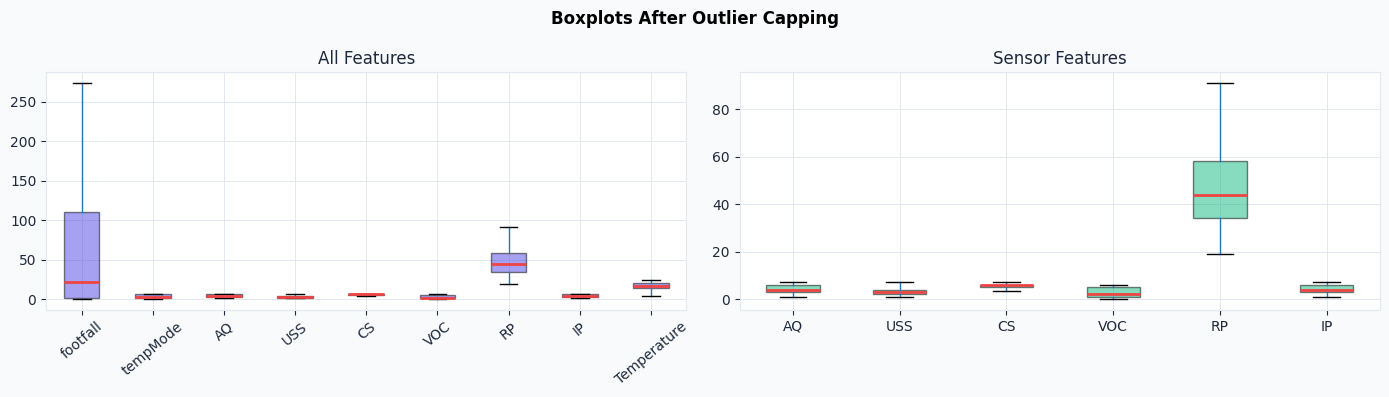

In [7]:
# Visualise before/after via boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Boxplots After Outlier Capping", fontweight="bold")

df[features].boxplot(ax=axes[0], patch_artist=True,
                     boxprops=dict(facecolor=PRIMARY, alpha=0.5),
                     medianprops=dict(color=DANGER, linewidth=2))
axes[0].set_title("All Features"); axes[0].tick_params(axis='x', rotation=40)

df[["AQ","USS","CS","VOC","RP","IP"]].boxplot(ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor=ACCENT, alpha=0.5),
    medianprops=dict(color=DANGER, linewidth=2))
axes[1].set_title("Sensor Features")
plt.tight_layout(); plt.show()

## 5. Exploratory Data Analysis (EDA)

### 5.1 Target Distribution

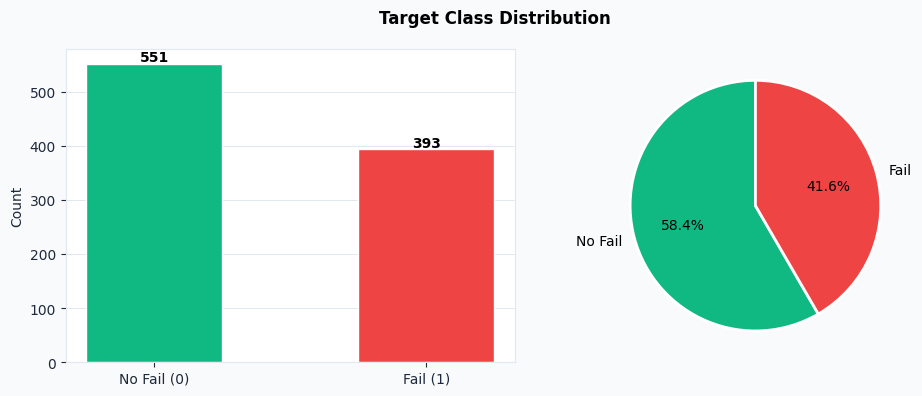

fail
0    551
1    393
Name: count, dtype: int64


In [8]:
counts = df[target].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Target Class Distribution", fontweight="bold")

bars = axes[0].bar(["No Fail (0)","Fail (1)"], counts.values,
                   color=[ACCENT, DANGER], edgecolor="white", width=0.5)
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+5,
                 str(b.get_height()), ha="center", fontweight="bold")
axes[0].set_ylabel("Count"); axes[0].grid(axis="y"); axes[0].set_axisbelow(True)

axes[1].pie(counts.values, labels=["No Fail","Fail"],
            colors=[ACCENT, DANGER], autopct="%1.1f%%",
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
plt.tight_layout(); plt.show()
print(counts)

### 5.2 Correlation Matrix

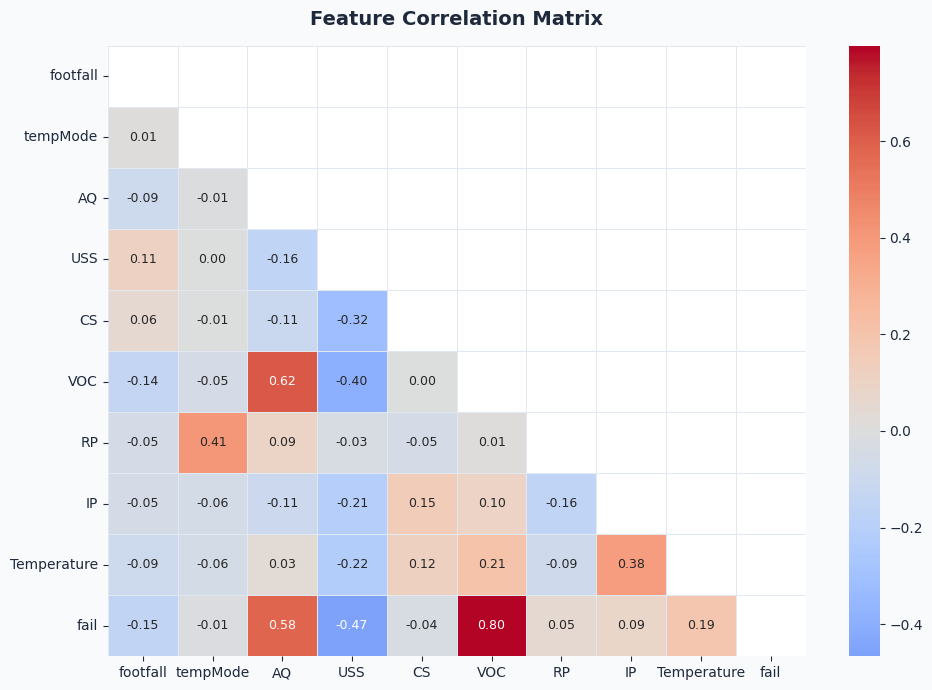

In [9]:
corr = df[features + [target]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, ax=ax, cmap="coolwarm", center=0,
            annot=True, fmt=".2f", annot_kws={"size": 9},
            linewidths=0.5, linecolor=GRID)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout(); plt.show()

### 5.3 Feature Distributions by Class

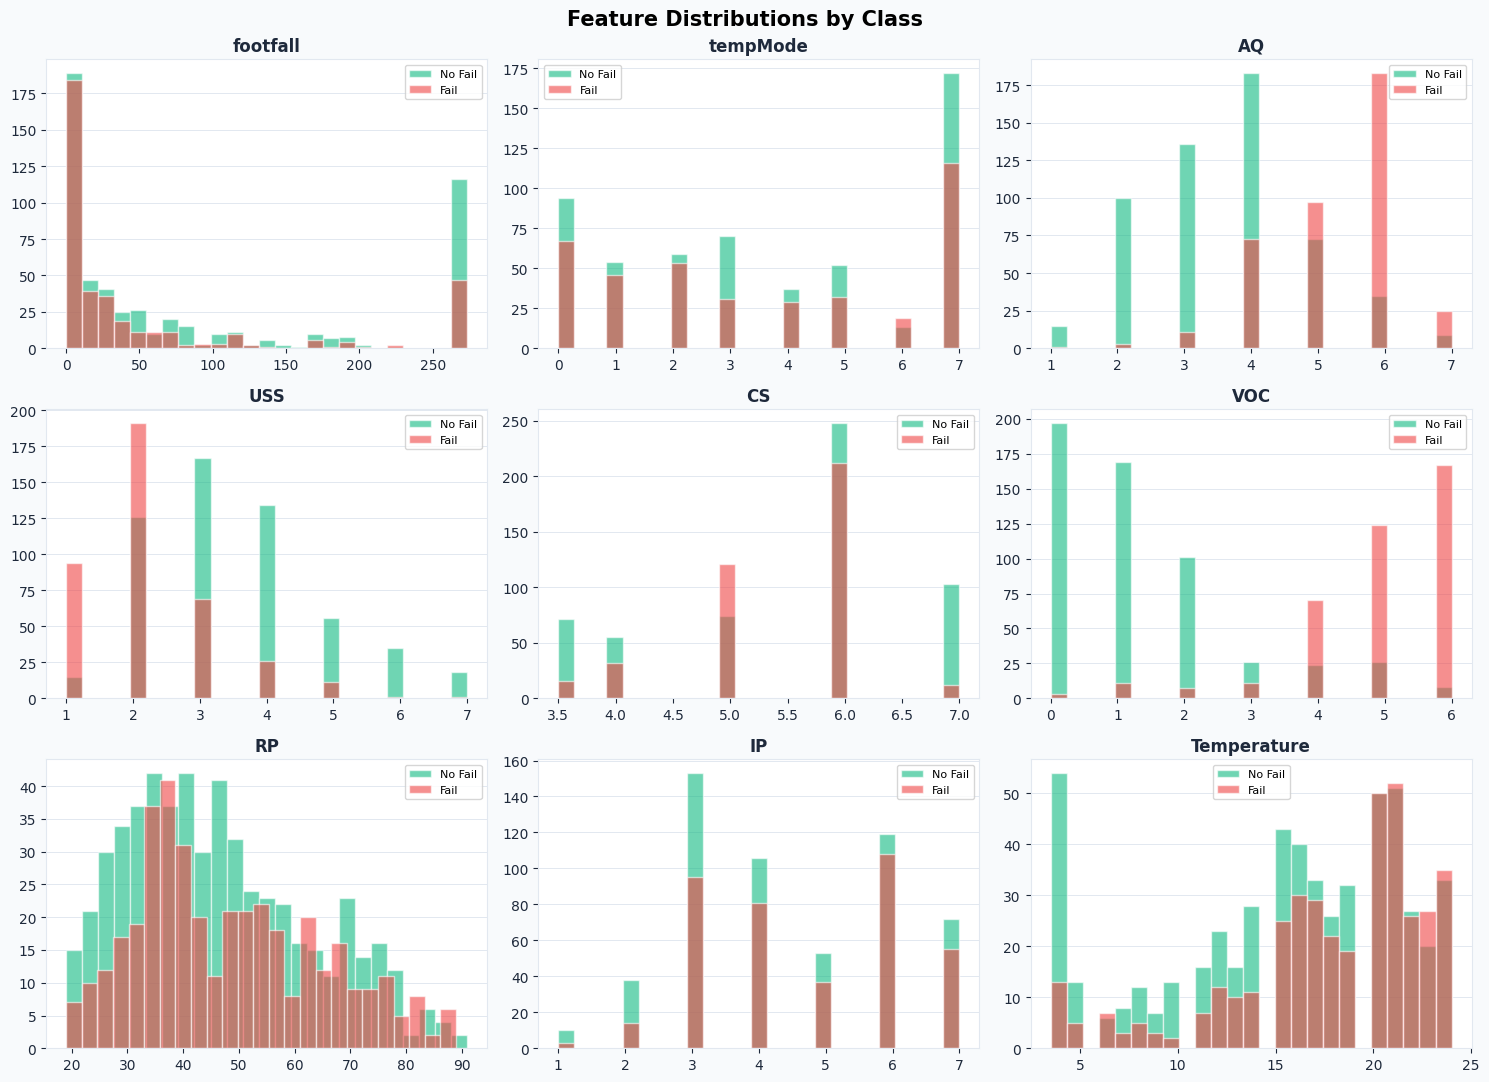

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
fig.suptitle("Feature Distributions by Class", fontsize=15, fontweight="bold")

for i, col in enumerate(features):
    ax = axes.flatten()[i]
    for label, color, name in [(0, ACCENT, "No Fail"), (1, DANGER, "Fail")]:
        ax.hist(df[df[target]==label][col], bins=25, alpha=0.6,
                color=color, label=name, edgecolor="white")
    ax.set_title(col, fontweight="bold")
    ax.legend(fontsize=8); ax.grid(axis="y"); ax.set_axisbelow(True)

plt.tight_layout(); plt.show()

### 5.4 Scatter Plots

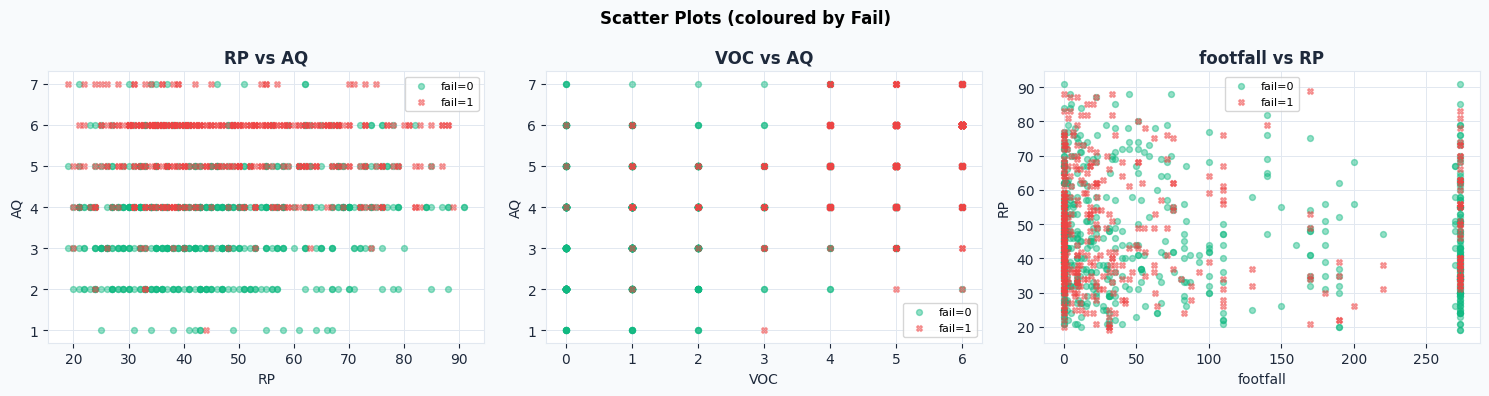

In [11]:
pairs = [("RP", "AQ"), ("VOC", "AQ"), ("footfall", "RP")]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Scatter Plots (coloured by Fail)", fontweight="bold")

for ax, (x_col, y_col) in zip(axes, pairs):
    for label, color, marker in [(0, ACCENT, "o"), (1, DANGER, "X")]:
        sub = df[df[target]==label]
        ax.scatter(sub[x_col], sub[y_col], c=color, label=f"fail={label}",
                   alpha=0.45, s=18, marker=marker)
    ax.set_xlabel(x_col); ax.set_ylabel(y_col)
    ax.set_title(f"{x_col} vs {y_col}", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(True); ax.set_axisbelow(True)

plt.tight_layout(); plt.show()

## 6. Averages

In [12]:
overall_avg = df[features].mean().round(3)
class_avg   = df.groupby(target)[features].mean().round(3)

print("Overall Feature Averages:")
print(overall_avg.to_frame(name="Mean").T)
print("\nAverages by Class:")
print(class_avg)

Overall Feature Averages:
      footfall  tempMode     AQ   USS     CS    VOC      RP     IP  \
Mean    74.929     3.728  4.325  2.94  5.501  2.842  47.043  4.566   

      Temperature  
Mean        16.41  

Averages by Class:
      footfall  tempMode     AQ    USS     CS    VOC      RP     IP  \
fail                                                                  
0       87.950     3.760  3.617  3.485  5.531  1.312  46.299  4.450   
1       56.673     3.682  5.318  2.176  5.458  4.987  48.087  4.728   

      Temperature  
fail               
0          15.486  
1          17.705  


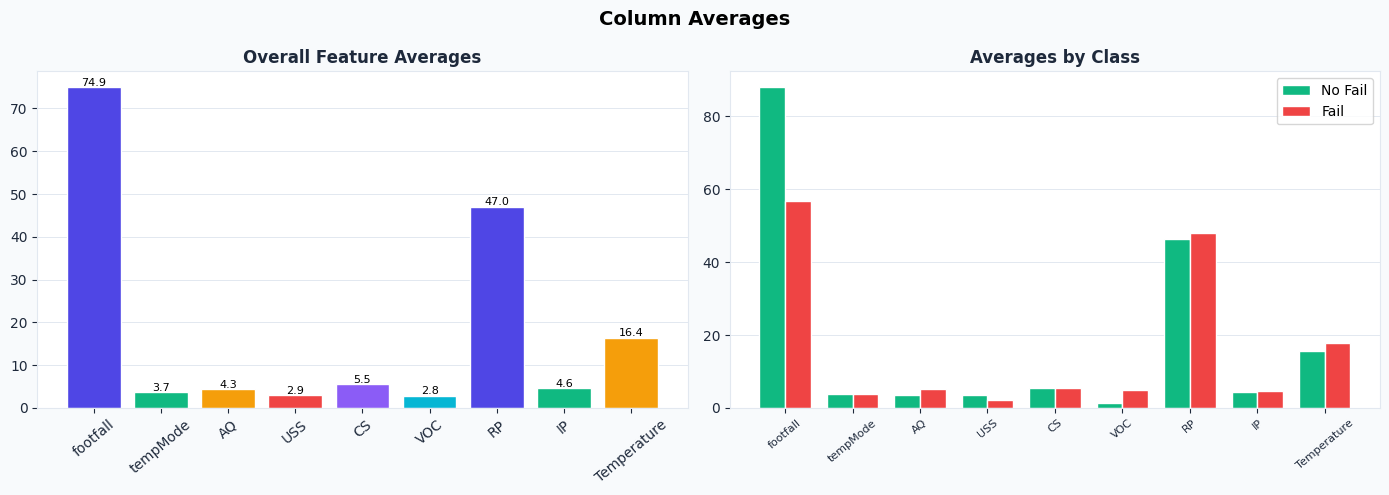

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Column Averages", fontsize=14, fontweight="bold")

# Overall
bars = axes[0].bar(overall_avg.index, overall_avg.values,
                   color=PALETTE[:len(overall_avg)], edgecolor="white")
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                 f"{b.get_height():.1f}", ha="center", fontsize=8)
axes[0].set_title("Overall Feature Averages", fontweight="bold")
axes[0].tick_params(axis='x', rotation=40); axes[0].grid(axis="y"); axes[0].set_axisbelow(True)

# By class
x = np.arange(len(features)); w = 0.38
axes[1].bar(x-w/2, class_avg.loc[0], width=w, label="No Fail", color=ACCENT, edgecolor="white")
axes[1].bar(x+w/2, class_avg.loc[1], width=w, label="Fail",    color=DANGER, edgecolor="white")
axes[1].set_xticks(x); axes[1].set_xticklabels(features, rotation=40, fontsize=8)
axes[1].set_title("Averages by Class", fontweight="bold")
axes[1].legend(); axes[1].grid(axis="y"); axes[1].set_axisbelow(True)

plt.tight_layout(); plt.show()

## 7. Logistic Regression Model

### 7.1 Train/Test Split & Scaling

In [14]:
X = df[features].values
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")
print(f"Train class balance — 0: {(y_train==0).sum()}  1: {(y_train==1).sum()}")
print(f"Test  class balance — 0: {(y_test==0).sum()}  1: {(y_test==1).sum()}")

Train size: 755  |  Test size: 189
Train class balance — 0: 441  1: 314
Test  class balance — 0: 110  1: 79


### 7.2 Train Model

In [15]:
model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model.fit(X_train_s, y_train)

y_pred  = model.predict(X_test_s)
y_proba = model.predict_proba(X_test_s)[:,1]

print("Model trained ✓")

Model trained ✓


### 7.3 Classification Report

In [16]:
print(classification_report(y_test, y_pred, target_names=["No Fail","Fail"]))

              precision    recall  f1-score   support

     No Fail       0.93      0.88      0.91       110
        Fail       0.85      0.91      0.88        79

    accuracy                           0.89       189
   macro avg       0.89      0.90      0.89       189
weighted avg       0.90      0.89      0.89       189



### 7.4 Confusion Matrix, ROC Curve & Feature Coefficients

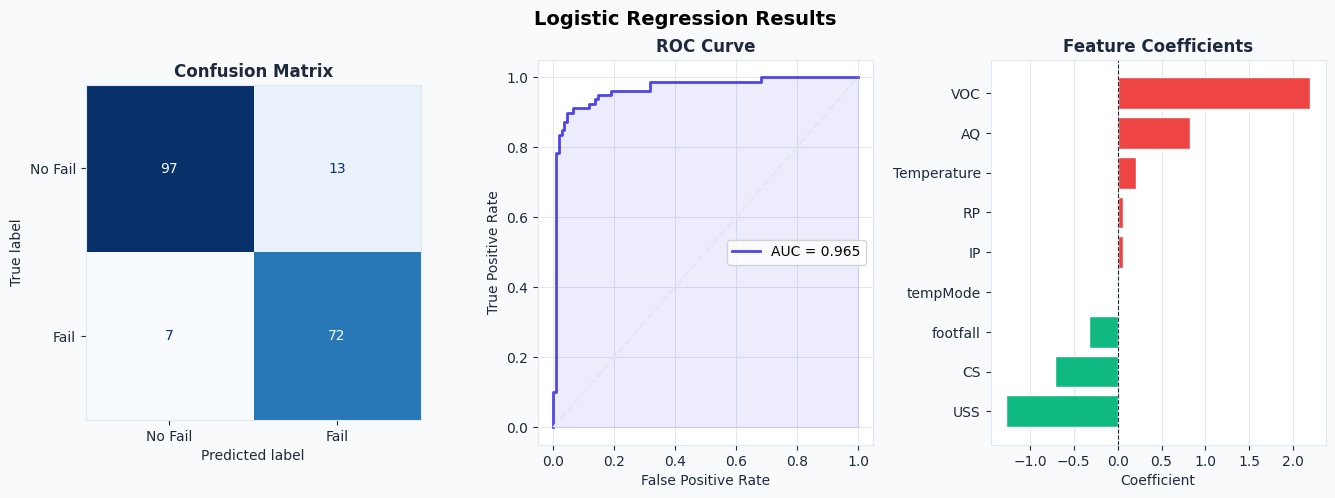


ROC-AUC Score: 0.9655


In [17]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

fig = plt.figure(figsize=(16, 5))
fig.suptitle("Logistic Regression Results", fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(1, 3, wspace=0.35)

# Confusion matrix
ax1 = fig.add_subplot(gs[0])
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Fail","Fail"]).plot(ax=ax1, colorbar=False, cmap="Blues")
ax1.set_title("Confusion Matrix", fontweight="bold"); ax1.grid(False)

# ROC curve
ax2 = fig.add_subplot(gs[1])
ax2.plot(fpr, tpr, color=PRIMARY, lw=2, label=f"AUC = {roc_auc:.3f}")
ax2.plot([0,1],[0,1],"--", color=GRID, lw=1.5)
ax2.fill_between(fpr, tpr, alpha=0.1, color=PRIMARY)
ax2.set_xlabel("False Positive Rate"); ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curve", fontweight="bold")
ax2.legend(); ax2.grid(True); ax2.set_axisbelow(True)

# Feature coefficients
ax3 = fig.add_subplot(gs[2])
coefs = pd.Series(model.coef_[0], index=features).sort_values()
colors = [DANGER if v > 0 else ACCENT for v in coefs.values]
ax3.barh(coefs.index, coefs.values, color=colors, edgecolor="white")
ax3.axvline(0, color=TEXT, linewidth=0.8, linestyle="--")
ax3.set_title("Feature Coefficients", fontweight="bold")
ax3.set_xlabel("Coefficient"); ax3.grid(axis="x"); ax3.set_axisbelow(True)

plt.tight_layout(); plt.show()
print(f"\nROC-AUC Score: {roc_auc:.4f}")

### 7.5 Feature Importance Summary

In [18]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0],
    "Abs Coefficient": np.abs(model.coef_[0])
}).sort_values("Abs Coefficient", ascending=False).reset_index(drop=True)

importance_df["Direction"] = importance_df["Coefficient"].apply(
    lambda x: "↑ Increases Fail Risk" if x > 0 else "↓ Decreases Fail Risk")

print("Feature Importance (by absolute coefficient):")
importance_df

Feature Importance (by absolute coefficient):


,Feature,Coefficient,Abs Coefficient,Direction
0,VOC,2.195996,2.195996,↑ Increases Fail Risk
1,USS,-1.274840,1.274840,↓ Decreases Fail Risk
2,AQ,0.819176,0.819176,↑ Increases Fail Risk
3,CS,-0.708664,0.708664,↓ Decreases Fail Risk
4,footfall,-0.323833,0.323833,↓ Decreases Fail Risk
5,Temperature,0.212354,0.212354,↑ Increases Fail Risk
6,RP,0.061973,0.061973,↑ Increases Fail Risk
7,IP,0.058721,0.058721,↑ Increases Fail Risk
8,tempMode,-0.000389,0.000389,↓ Decreases Fail Risk


## 8. Summary

| Step | Result |
|---|---|
| Missing values | None found |
| Outliers capped | footfall (154), CS (87), Temperature (48) |
| Dataset size | 944 rows, 10 columns |
| Class balance | 551 No-Fail / 393 Fail |
| Model accuracy | **89%** |
| ROC-AUC | **0.966** |
| Top fail predictors | AQ ↑, VOC ↑, footfall ↓ |